# LSN Exercises 03
## Black-Scholes Monte Carlo

Gabriele Borroni (14768A)

---

## Stochastic calculus
### Wiener processes
The study of natural processes that exhibit stochastic behavior led to the development of new mathematical tools, known as **stochastic calculus**.  
This framework extends the formalism of ordinary differential equations to deal with trajectories that are continuous but non-differentiable, capturing systems that evolve in a non-deterministic manner.  

One of the earliest and most important applications is the description of **Brownian motion**, where particles appear to be in constant agitation, undergoing fast and random displacements.  
In 1923, **Norbert Wiener** provided a rigorous foundation for this process, showing that it can be modeled as a random walk with independent and identically distributed Gaussian increments.  
$$

W(t_{i+1}) = W(t_i) + Z_{i+1}\sqrt{\,t_{i+1} - t_i\,}, 
\qquad i = 0,1,\dots


$$

The resulting **Wiener process** displays some remarkable properties:
- its sample paths are continuous yet nowhere differentiable,  
- it is **self-similar**, meaning that any finite segment of $W(t)$, once rescaled, is statistically indistinguishable from the entire trajectory.

### Stochastic processes
A process $X(t)$ is defined as a **Brownian motion with drift** $\mu$ and **diffusion coefficient** $\sigma^2$, abbreviated as

$$
X \sim BM(\mu, \sigma^2),
$$

if

$$
\frac{X(t) - \mu t}{\sigma} \sim BM(0,1),
$$

i.e. it reduces to the standard Brownian motion when $\mu = 0$ and $\sigma = 1$.  
This allows to construct a general Brownian motion $X$ from the standard Wiener process $W$.

 For deterministic but time-dependent $\mu(t)$ and $\sigma(t)$, one can define Brownian motion with the more general **stochastic differential equation (SDE):**

$$
dX_t = \mu(t)\,dt + \sigma(t)\,dW_t.
$$

---

### Sampling Brownian Motion

Let $Z_1, \dots, Z_n$ be independent standard normal random variables ($Z_i \sim \mathcal{N}(0,1)$).  
Starting with $t_0 = 0$ and $W(0)=0$, the Wiener process can be sampled as

$$
W(t_{i+1}) = W(t_i) + Z_{i+1}\sqrt{t_{i+1} - t_i}, 
\quad i = 0,1,\dots,n-1.
$$

For a Brownian motion with drift and diffusion, $X \sim BM(\mu,\sigma^2)$, and initial condition $X(0)=0$, the path is generated by

$$
X(t_{i+1}) = X(t_i) + \mu (t_{i+1}-t_i) + \sigma Z_{i+1}\sqrt{t_{i+1}-t_i}, 
\quad i = 0,1,\dots,n-1.
$$
In the **geometric Brownian motions** formalism, this tools have been used to model the finantial market.

## Basic Notions of Financial Markets

A **market** is a place where buyers and sellers meet to exchange goods, each of which has a price at every moment in time, called the **spot price**.  
This price results from the interaction between supply and demand.  

A **financial market** is a particular type of market where the "product" being traded is money itself, either lent, borrowed, or invested in instruments such as commodities, bonds, or stocks.  
Transactions in these markets take the form of **contracts** between participants (agents), who are willing to accept a certain level of risk in exchange for the possibility of significant profits.  

In financial markets, the **evolution of asset values** over time is highly unpredictable.  
This unpredictability does not stem from a lack of information, but rather from an overabundance of it, making it difficult to link specific pieces of economic data to precise aspects of price movements.  


### Efficient Markets

A market is considered **efficient** if:
- agents can easily access the information needed to trade,  
- it is **liquid**, meaning assets can be bought or sold at any time,  
- and **transaction costs** are negligible compared to the volumes exchanged.  

In practice, real markets are only **approximately efficient**, which leads to the **Markov assumption**, now widely confirmed.  
For example, if the price of an asset is expected to rise, investors will buy it in order to resell it at a profit.  
However, this increase in demand immediately drives the price up, causing the profit opportunity to disappear within a short period.  

As a result, any correlation between the **future price** and the **current state** of an asset exists only over very short time horizons, supporting the idea that financial time series behave in a largely random fashion.

## Options

In simple terms, **options** are contracts where one party takes on an obligation and the other receives a right.  
The most basic ones are **European options**, often called *plain vanilla options*.  
The seller of the option, known as the *writer*, grants the buyer (the *holder*) the right to either buy (call option) or sell (put option) an underlying asset with current spot price $S(t)$, at a predetermined price $K$ (the **strike price**), exercisable at the maturity date $T$.  
The holder will choose whether to exercise the option depending on profitability.

$$
P_{\text{call}} = \max\big[0,\, S(T) - K\big]
\qquad
P_{\text{put}} = \max\big[0,\, K - S(T)\big]
$$

The main challenge is to correctly determine the fair price of these contracts.  
For more complex derivatives, numerical techniques such as Monte Carlo simulations are often needed.  
For European options, however, the **Black–Scholes theory** provides a closed-form solution.


## Black–Scholes theory

The model assumes that the asset price follows a stochastic process, specifically a **geometric Brownian motion (GBM)**, under constant risk-free interest rate $r$ and constant volatility $\sigma$.

The Black–Scholes analytic solution for the price at time $t < T$ is:

- **European Call option:**

$$
C[S(t),t] = S(t)N(d_1) - K e^{-r(T-t)} N(d_2)
$$

- **European Put option:**

$$
P[S(t),t] = S(t)\,[N(d_1) - 1] - K e^{-r(T-t)}\,[N(d_2) - 1]
$$

where

$$
d_1 = \frac{1}{\sigma \sqrt{T-t}} \left[ \ln\!\left(\frac{S(t)}{K}\right) + \Big(r + \tfrac{\sigma^2}{2}\Big)(T-t) \right],
$$

and

$$
d_2 = d_1 - \sigma \sqrt{T-t}.
$$

Finally, $N(x)$ is the cumulative distribution of the standard Gaussian:

$$
N(x) = \int_{-\infty}^x e^{-z^2/2}\,dz 
= \tfrac{1}{2}\Big[1 + \operatorname{erf}\!\left(\tfrac{x}{\sqrt{2}}\right)\Big].
$$

Where

$$
\operatorname{erf}(x) = \frac{2}{\sqrt{\pi}} \int_0^x e^{-z^2}\,dz.
$$

 
To compute the present value of the payoff (at time $t$), the future profit must be discounted by the factor $e^{-rT}$, which accounts for the interest a bank would have provided on a risk-free deposit starting at $t_0 = 0$.  

Thus, the option price corresponds to the expected value of the discounted payoff over the distribution of prices at maturity:

$$
\Big\langle e^{-rT}\,(S(T) - K)^+ \Big\rangle
$$

This represents the amount the holder of the option should pay at $t = 0$, based on the expected profit at $t = T$.  
### Brownian Motion and Monte Carlo Simulation

To evaluate an option using **Monte Carlo simulation**, the procedure is:

- Generate multiple simulated paths of the asset price $S(T)$  
- Compute the payoff for each simulated path  
- Average the discounted payoffs (data blocking)


#### 1. Direct sampling

The terminal price $S(T)$ can be generated directly from the closed-form solution of the Geometric Brownian Motion (GBM):

$$
S(T) = S_0 \exp \left[ \left(r - \tfrac{\sigma^2}{2}\right) T + \sigma z \sqrt{T} \right],
$$

where $z \sim \mathcal{N}(0,1)$ is a standard normal random variable.



#### 2. Discretized sampling

Alternatively, the time interval $[0, T]$ is divided into $N$ sub-intervals, and the asset price is simulated step by step:

$$
S_{t+\Delta t} = S_t \exp \left[ \left(r - \tfrac{\sigma^2}{2}\right)\Delta t + \sigma z \sqrt{\Delta t} \right],
$$

with a new random draw $z$ at each step.

Results below show the Monte Carlo calculated values for discrete and continuous sampling for call and put.
A comparison with the analytical solution derived in the Black-Scholes theory shows the reliability of the results obtained.





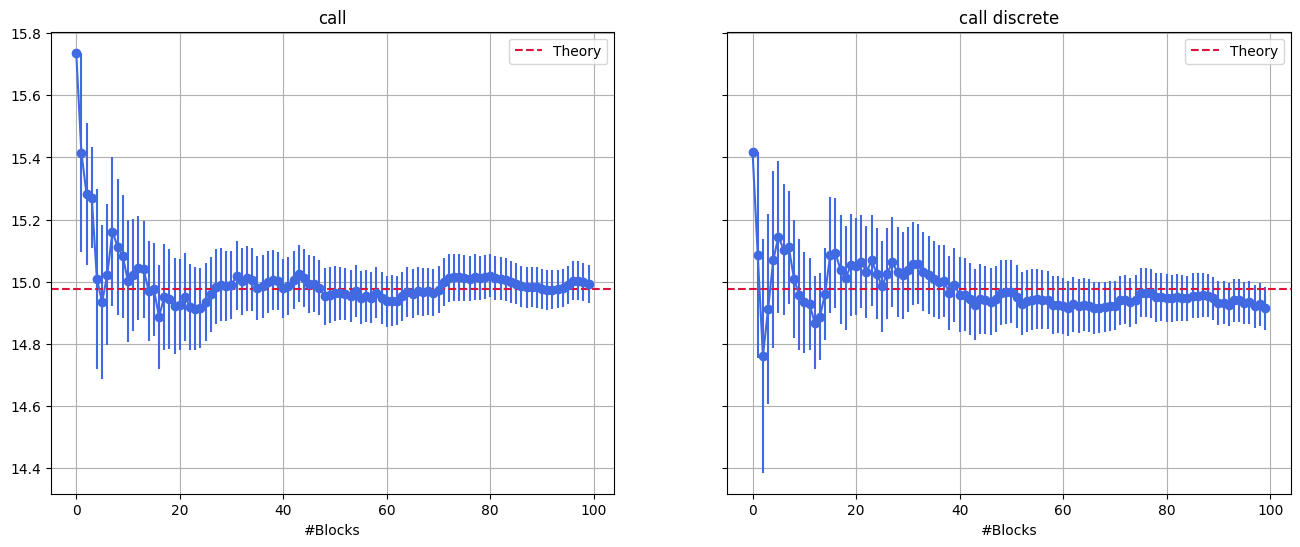

<CD>= 14.972913
<CC>= 15.001638000000003


In [3]:
import matplotlib 
import matplotlib.pyplot as plt
import numpy as np

data_call=np.loadtxt("OUTPUT/Call.dat")
yc=data_call[:,1]
erryc=data_call[:,2]

N=data_call.shape[0]
x=np.arange(N)


data_call_d=np.loadtxt("OUTPUT/Call_discrete.dat")
yc_d=data_call_d[:,1]
erryc_d=data_call_d[:,2]

theory=14.9758

fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
axs[0].errorbar(x,yc, yerr=erryc, color='RoyalBlue', fmt='-o')
axs[0].set_title("call")
axs[0].set_xlabel("#Blocks")
axs[0].grid(True)
axs[0].axhline(y=theory, color='crimson', linestyle='--', label='Theory')

axs[0].legend()

axs[0].set_xlabel("#Blocks")
axs[1].errorbar(x,yc_d, yerr=erryc_d, color='RoyalBlue', fmt='-o')
axs[1].set_title("call discrete")
axs[1].set_xlabel("#Blocks")
axs[1].grid(True)
axs[1].axhline(y=theory, color='crimson', linestyle='--', label='Theory')
axs[1].legend()




plt.show()


print(f"<CD>=",np.mean(yc_d))
print(f"<CC>=",np.mean(yc))





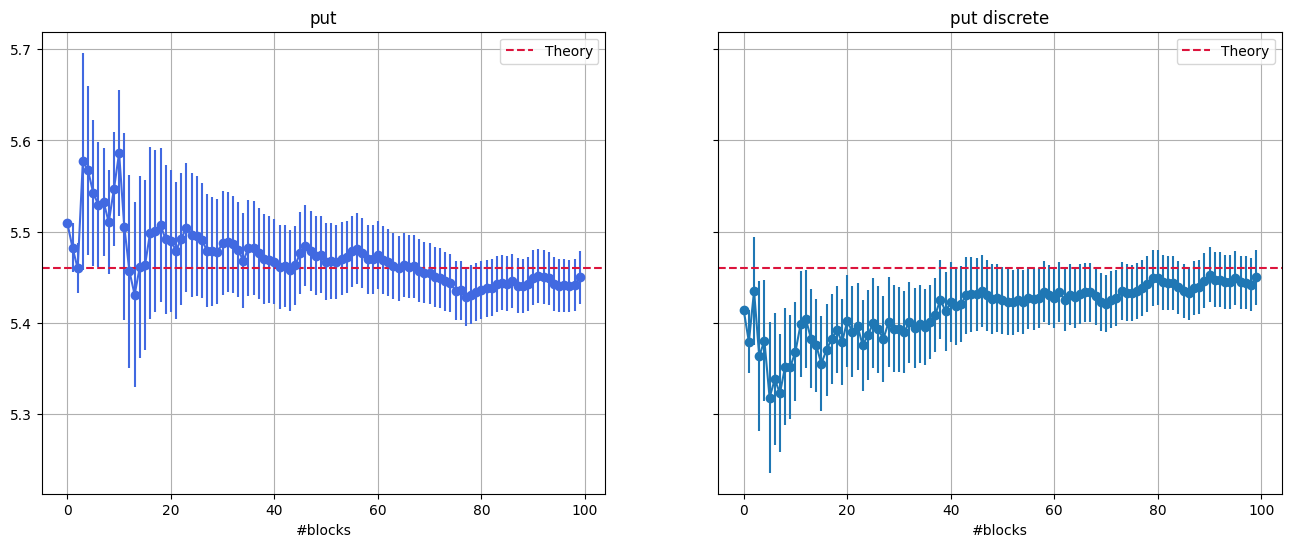

<PD>= 5.4143269
<PC>= 5.471424100000002


In [5]:


data_put=np.loadtxt("OUTPUT/Put.dat")
yp=data_put[:,1]
erryp=data_put[:,2]

data_put_d=np.loadtxt("OUTPUT/Put_discrete.dat")
yp_d=data_put_d[:,1]
erryp_d=data_put_d[:,2]

theory = 5.4595

fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

axs[0].errorbar(x,yp, yerr=erryp, color='RoyalBlue', fmt= '-o' )
axs[0].set_title("put")
axs[0].grid(True)
axs[0].set_xlabel("#blocks")
axs[0].axhline(y=theory, color='crimson', linestyle='--', label='Theory')
axs[0].legend()

axs[1].errorbar(x,yp_d, yerr=erryp_d, fmt= '-o')
axs[1].set_title("put discrete")
axs[1].set_xlabel("#blocks")
axs[1].grid(True)
axs[1].axhline(y=theory, color='crimson', linestyle='--', label='Theory')
axs[1].legend()
plt.show()
print(f"<PD>=",np.mean(yp_d))
print(f"<PC>=",np.mean(yp))